# GAM

Comparing the different implementations of GAM, **R(mgcv)** is the only one that is reliably providing output with accuracy and without error.

- statsmodels
  - This model does work when there are no weights.
  - However, when using weights the model does not provide the expected response. A user may be able to build out a weighted function where it splits out those weights manually.
  - Another option was to use failure/success in the model, however that seemed to create output errors.
  - https://www.statsmodels.org/stable/generated/statsmodels.gam.generalized_additive_model.GLMGam.html#
- pygam
  - pygam does seem to work, however it has more warnings and isn't actively maintained
  - https://github.com/dswah/pyGAM
- R(mgcv)
  - Seems to be actively maintained and does not cause warnings.
  - The process does take longer as data gets copied into R environments
  - https://cran.r-project.org/web/packages/mgcv/

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import polars as pl

os.chdir("../../")
sys.path.insert(0, os.getcwd())

In [13]:
from morai.experience import charters, tables
from morai.forecast import metrics, preprocessors
from morai.models import core, r
from morai.utils import custom_logger, helpers

In [3]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

# Data

In [4]:
test_forecast_path = helpers.ROOT_PATH / "tests" / "files" / "forecast" / "models"
sigmoid_data = pd.read_csv(test_forecast_path / "sigmoid_data.csv")
feature_dict = {
    "target": ["rate"],
    "weight": ["weight"],
    "passthrough": ["age", "gender", "faceband"],
}
preprocess_dict = preprocessors.preprocess_data(
    sigmoid_data,
    feature_dict=feature_dict,
    standardize=False,
    add_constant=True,
)
X = preprocess_dict["X"]
y = preprocess_dict["y"]
weights = preprocess_dict["weights"]

 2025-10-06 21:55:34 | morai.forecast.preprocessors | INFO     | model target: ['rate'] 
 2025-10-06 21:55:34 | morai.forecast.preprocessors | INFO     | model weights: ['weight'] 
 2025-10-06 21:55:34 | morai.forecast.preprocessors | INFO     | adding a constant column to the data 
 2025-10-06 21:55:34 | morai.forecast.preprocessors | INFO     | passthrough - (generally numeric): ['faceband', 'gender', 'age', 'constant'] 


# Comparison

## Statsmodels

In [5]:
GAM = core.GAMStats()
spline_dict = {
    "age": {"df": 12, "degree": 3},
}
GAM.setup_model(X=X, y=y, weights=weights, spline_dict=spline_dict, alpha=0)
GAM.fit()

 2025-10-06 21:55:40 | morai.models.core | INFO     | setup GAM model with statsmodels and <class 'statsmodels.genmod.families.family.Binomial'> family... 
 2025-10-06 21:55:40 | morai.models.core | INFO     | created splines for `['age']` 
 2025-10-06 21:55:40 | morai.models.core | INFO     | fiting the model 
 2025-10-06 21:55:40 | morai.models.core | INFO     | `12` degrees of freedom for smoother with `11.55` being effective 


In [6]:
print(GAM.model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   rate   No. Observations:                  480
Model:                         GLMGam   Df Residuals:                  -234.92
Model Family:                Binomial   Df Model:                       713.92
Link Function:                  Logit   Scale:                          1.0000
Method:                         PIRLS   Log-Likelihood:                -3040.4
Date:                Mon, 06 Oct 2025   Deviance:                       1177.1
Time:                        21:55:45   Pearson chi2:                     790.
No. Iterations:                    11   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
constant      -8.7990      9.664     -0.910      0.3

In [7]:
predictions = GAM.predict(X)
sigmoid_data["sm"] = predictions

## Pygam

In [8]:
GAMPy = core.GAMPy()

In [9]:
spline_dict = {
    "age": {"df": 12, "degree": 3},
}
GAMPy.setup_model(X=X, y=y, weights=weights, spline_dict=spline_dict, alpha=0)

 2025-10-06 21:55:56 | morai.models.core | INFO     | setup GAM model with pygam and `binomial` distribution with `logit` link 


GAM(callbacks=['deviance', 'diffs'], distribution='binomial', 
   fit_intercept=False, lam=0, link='logit', max_iter=100, 
   terms=s(0) + l(1) + l(2) + l(3), tol=0.0001, verbose=False)

In [10]:
GAMPy.fit()

 2025-10-06 21:55:59 | morai.models.core | INFO     | fiting the model 


C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\pygam\pygam.py:1150: RuntimeWarning:

invalid value encountered in scalar divide

C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\pygam\pygam.py:1151: RuntimeWarning:

invalid value encountered in scalar divide



GAM(callbacks=[Deviance(), Diffs()], 
   distribution=BinomialDist(levels=1), fit_intercept=False, 
   link=LogitLink(), max_iter=100, terms=s(0) + l(1) + l(2) + l(3), 
   tol=0.0001, verbose=False)

In [11]:
GAMPy.model.summary()

GAM                                                                                                       
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                        14.0
Link Function:                        LogitLink Log Likelihood:                                       -inf
Number of Samples:                          480 AIC:                                                   inf
                                                AICc:                                                  inf
                                                UBRE:                                               2.3273
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.9958
Feature Function                  Lam

C:\Users\johnk\AppData\Local\Temp\ipykernel_15524\1557638170.py:1: UserWarning:

KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 




In [12]:
predictions = GAMPy.predict(X)
sigmoid_data["pygam"] = predictions

## R (mgcv)

In [14]:
GAMR = r.GAMR()
spline_dict = {
    "age": {"df": 12, "degree": 3, "bs":"ps"},
}

In [15]:
GAMR.setup_model(X=X, y=y, weights=weights, spline_dict=spline_dict)

 2025-10-06 21:56:35 | morai.models.r | INFO     | setup GAM model with mgcv and `quasibinomial` distribution with `logit` link 
 2025-10-06 21:56:40 | morai.models.r | INFO     | formula: 
 2025-10-06 21:56:40 | morai.models.r | INFO     | > rate ~ s(`age`, k=12, m=3, bs='ps')+`constant`+`faceband`+`gender` 
 2025-10-06 21:56:40 | morai.models.r | INFO     | fitting the model: 
 2025-10-06 21:56:40 | morai.models.r | INFO     | > model <- bam(formula, data=data, weights=weights, family=family, drop.intercept=TRUE)` 
 2025-10-06 21:56:41 | morai.models.r | INFO     | model fitted 


In [16]:
print(GAMR.summary(expand=True))

Generalized Additive Model (mgcv) Summary
Family                : quasibinomial
Link                  : logit
Number of Observations: 480
Adjusted R-squared    : 0.998
Deviance Explained    : 99.5%
Scale Estimate        : 0.8419
fREML                 : 646.1

Formula:
rate ~ s(`age`, k=12, m=3, bs='ps')+`constant`+`faceband`+`gender`

Parametric Coefficients:
constant   -4.004392e+00
faceband    5.040397e+00
gender     -2.424741e-15

Smooth Terms:
             edf    Ref.df           F  p-value      alpha
s(age)  5.181695  5.847285  870.747807      0.0  44.384753

Expanded Smooth Terms:
         name       coef
3    s(age).1  -1.797458
4    s(age).2  -1.997472
5    s(age).3  -0.613487
6    s(age).4   2.037228
7    s(age).5   5.088429
8    s(age).6   8.306820
9    s(age).7  10.532351
10   s(age).8  11.034027
11   s(age).9  10.703045
12  s(age).10  10.069730
13  s(age).11   9.169025


In [17]:
predictions = GAMR.predict(X)
sigmoid_data["r"] = predictions

 2025-10-06 21:56:44 | morai.models.r | INFO     | predicted rates 


## Compare

 2025-10-06 22:03:45 | morai.experience.charters | INFO     | The weights list is 1 long and should be 4 long. Using the first weight for all weights. 


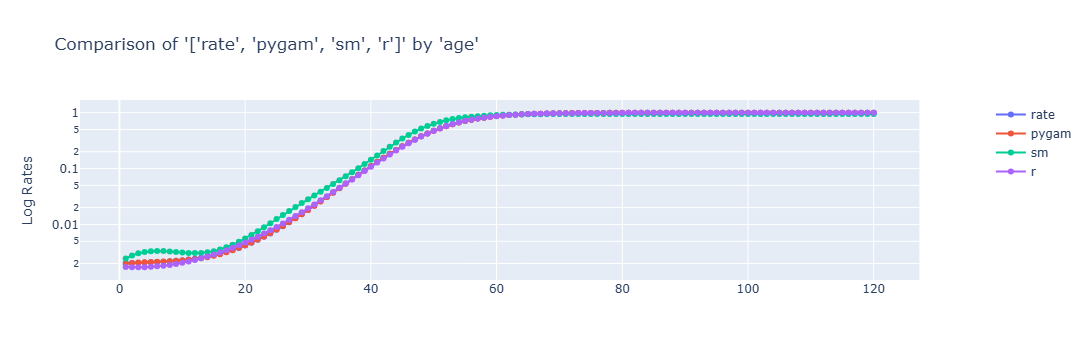

In [20]:
charters.compare_rates(
    df=sigmoid_data,
    x_axis="age",
    rates=["rate", "pygam", "sm", "r"],
    weights=["weight"],
    display=True,
    y_log=True,
)

# Test

In [25]:
import importlib

importlib.reload(core)

<module 'morai.models.gam' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\models\\gam.py'>

## Statsmodels Stack

In [7]:
import statsmodels.api as sm
from statsmodels.gam.api import BSplines, GLMGam

deaths = np.round(y * weights).astype(int)
failures = weights - deaths

endog2 = np.column_stack([deaths, failures])
bs = BSplines(X[["age"]], df=[12], degree=[3])
gam = GLMGam(
    endog=endog2,
    exog=X.drop(columns=["age"]),
    smoother=bs,
    family=sm.families.Binomial(),
)
res = gam.fit()

C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\families\links.py:257: RuntimeWarning: divide by zero encountered in divide
  return (2 * p - 1) / v ** 2
C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:576: RuntimeWarning: invalid value encountered in multiply
  tmp = score_factor * tmp


In [8]:
smoother_cols = bs.variable_names
non_smoother_cols = [col for col in X.columns if col not in smoother_cols]
predictions = np.array(
    res.predict(exog=X[non_smoother_cols], exog_smooth=X[smoother_cols])
)

C:\Users\johnk\miniconda3\envs\morai\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


In [9]:
sigmoid_data["sm_stack"] = predictions